# Setup & Dataset Exploration
loading the dataset, checking for missing or incorrect values.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/framingham.csv')

# View first few rows
df.head()

# Check structure and types
df.info()

# Summary statistics
df.describe()

# Check for missing values
df.isnull().sum()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


# Data Preprocessing
Clean your data to make it machine learning-ready.

In [5]:
# Fill or drop missing values
df = df.dropna()

# Optional: Normalize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Confirm changes
scaled_df.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1.119755,-1.232580,1.975209,-0.978364,-0.757169,-0.176901,-0.075987,-0.672860,-0.166784,-0.949108,-1.194111,-1.078881,0.292050,0.356370,-0.203044,-0.423815
1,-0.893053,-0.414905,0.019249,-0.978364,-0.757169,-0.176901,-0.075987,-0.672860,-0.166784,0.298294,-0.514881,-0.160118,0.725010,1.608469,-0.244883,-0.423815
2,1.119755,-0.181283,-0.958730,1.022114,0.920689,-0.176901,-0.075987,-0.672860,-0.166784,0.184894,-0.220548,-0.243642,-0.108929,-0.060996,-0.495920,-0.423815
3,-0.893053,1.337256,0.997229,1.022114,1.759618,-0.176901,-0.075987,1.486194,-0.166784,-0.268707,0.798296,1.009217,0.688110,-0.895729,0.884782,2.359518
4,-0.893053,-0.414905,0.997229,1.022114,1.172368,-0.176901,-0.075987,-0.672860,-0.166784,1.092095,-0.107344,0.090454,-0.659969,0.773736,0.131672,-0.423815


# Model Building
Train models to predict glucose using the features.

In [7]:
from sklearn.model_selection import train_test_split #splits it into training set and testing set
from sklearn.linear_model import LinearRegression

x = scaled_df.drop('glucose', axis = 1)
y = scaled_df['glucose']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

# Model Evaluation
To evaluate how good your model is at predicting.

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred) # Formula: average of all squared errors between predicted and actual values

r2 = r2_score(y_test, y_pred) # This calculates how much of the variance in glucose levels is explained by your model.
print("MSE: ", mse)
print("R^2 Score: ", r2)



MSE:  0.7477454688629037
R^2 Score:  0.4863459891319897


# Building a Random Forest Regressor


In [9]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results: ")
print("MSE: ", rf_mse)
print("R² Score: ", rf_r2)


Random Forest Results: 
MSE:  0.7227462361311182
R² Score:  0.5035188864560372


# Visualization Code

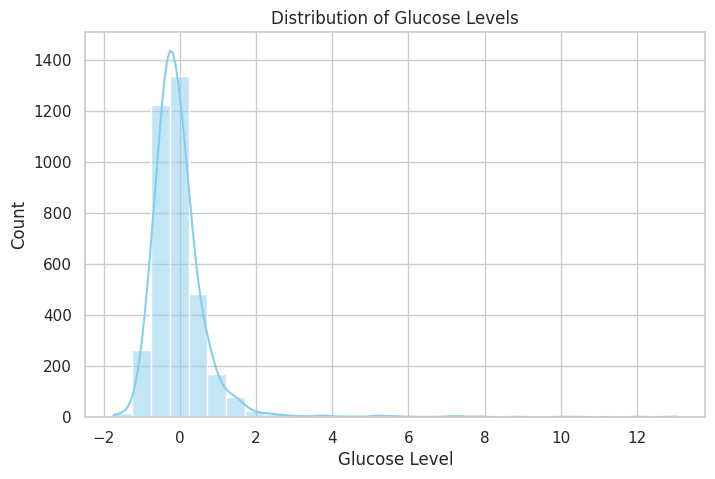

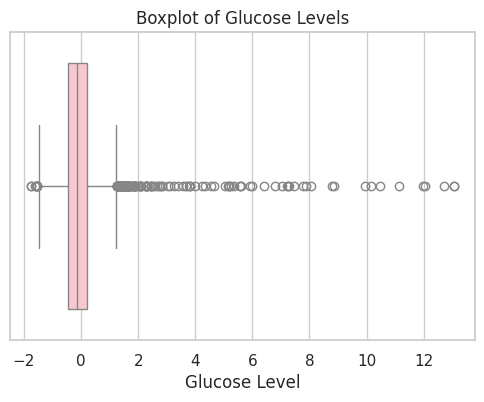

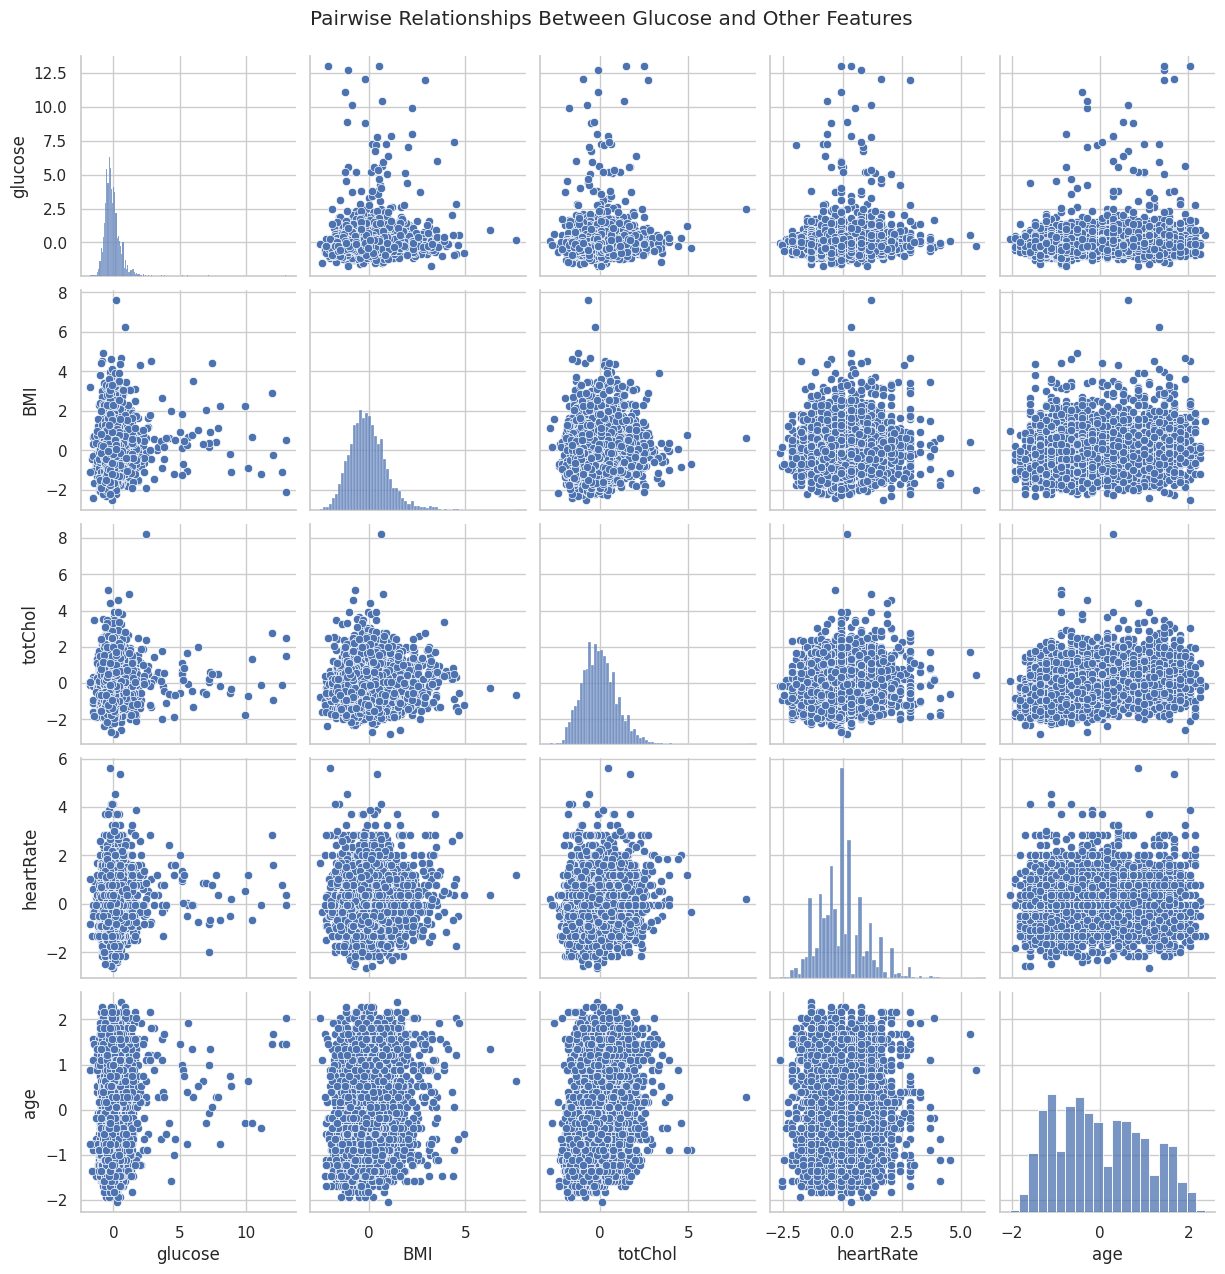

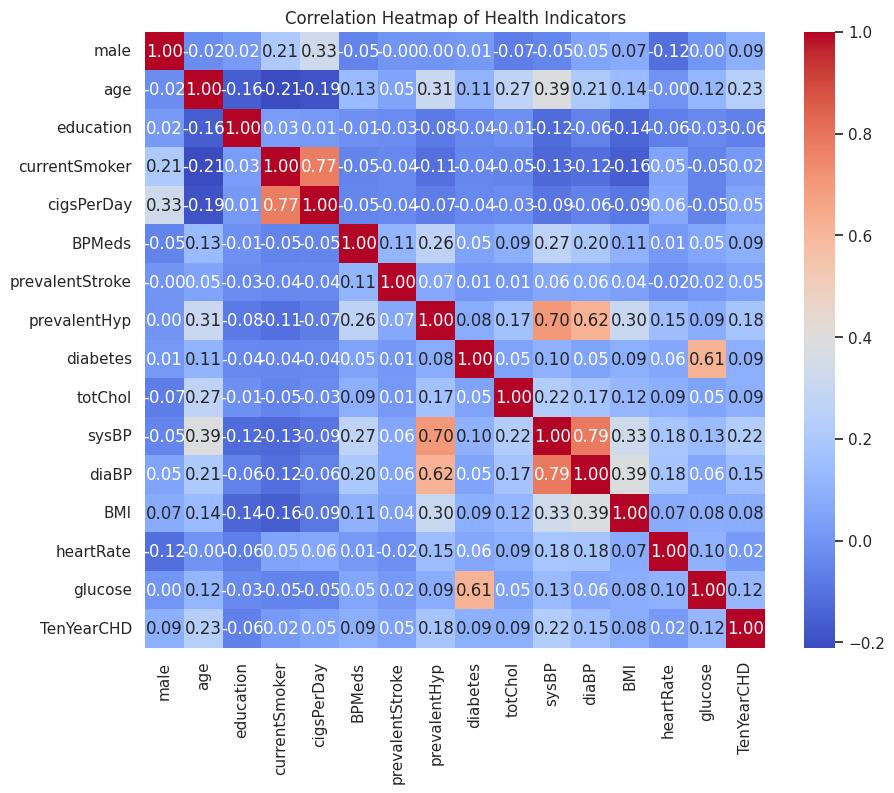

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Make plots prettier
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.histplot(scaled_df['glucose'], kde = True, color = 'skyblue', bins = 30)
plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose Level')
plt.ylabel('Count')
plt.show()



plt.figure(figsize = (6,4))
sns.boxplot(x=scaled_df['glucose'], color = 'pink')
plt.title('Boxplot of Glucose Levels')
plt.xlabel('Glucose Level')
plt.show()


selected_features = ['glucose', 'BMI', 'totChol', 'heartRate', 'age']
sns.pairplot(scaled_df[selected_features])
plt.suptitle('Pairwise Relationships Between Glucose and Other Features', y=1.02)
plt.show()

plt.figure(figsize=(10, 8))
corr = scaled_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Health Indicators')
plt.show()




# Retraining Models

In [14]:
from sklearn.model_selection import train_test_split

# Features and Target
X = scaled_df.drop(columns=['glucose'])
y = scaled_df['glucose']

# Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_predictions = lr_model.predict(X_test)

# Evaluate
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("🔹 Linear Regression Results:")
print("MSE:", lr_mse)
print("R² Score:", lr_r2)


from sklearn.ensemble import RandomForestRegressor

# Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("\n🔸 Random Forest Results:")
print("MSE:", rf_mse)
print("R² Score:", rf_r2)




🔹 Linear Regression Results:
MSE: 0.7477454688629037
R² Score: 0.4863459891319897

🔸 Random Forest Results:
MSE: 0.7227462361311182
R² Score: 0.5035188864560372


# Insights & Conclusion
Among the models tested, Random Forest outperformed Linear Regression in predicting glucose levels, with a slightly lower Mean Squared Error and higher R² Score, indicating better predictive performance.